# INESDI - Práctica - Modelos Básicos de Machine Learning

1 - Importamos las librerías que van a ser necesarias para la ejecución del código:

*   pandas: Manejo de datos tabulares.
*   numpy: Operaciones matemáticas (aunque aquí lo usamos mínimamente).
*   train_test_split: Divide los datos en entrenamiento y prueba.
*   StandardScaler: Escala los datos numéricos.
*   RandomForestClassifier: Modelo de clasificación basado en árboles de decisión.
*   classification_report, confusion_matrix, accuracy_score: Métricas para evaluar el modelo.
*   joblib: Guardar el modelo entrenado para uso futuro.

In [1]:
# Análisis y Modelado del Dataset
# Este notebook contiene los pasos para procesar un dataset y entrenar un modelo de clasificación.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Los 4 modelos que probaremos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


2 - Carga de del Dataset


*   Se carga el archivo CSV en un DataFrame de pandas para análisis.
*   Luego, inspeccionamos las primeras filas (head()) y obtenemos información básica sobre las columnas y tipos de datos (info()).



In [2]:
from google.colab import files
uploaded = files.upload()  # Esto abrirá un cuadro de diálogo para que selecciones el archivo

Saving marketing_campaign_retail_Enero.xlsx to marketing_campaign_retail_Enero.xlsx


In [3]:
# Cambia la ruta del archivo según tu entorno
data = pd.read_excel('marketing_campaign_retail_Enero.xlsx')

print("Primeras filas:")
display(data.head())

print("\nInformación del dataset:")
data.info()

Primeras filas:


,Client ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Client ID            2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurc

3- Preprocesamiento

*   Eliminamos la columna CustomerID, ya que es solo un identificador y no contribuye al análisis.
*   Codificamos las variables categóricas en variables numéricas usando One-Hot Encoding. Esto crea columnas binarias para cada categoría."Drop_first = True" elimina una categoría para evitar multicolinealidad.
*   Verificamos si hay valores faltantes en el DataSet. Si los hubiera, tendríamos que manejarlos. En general si son pocos se suelen eliminar o rellenar con la media o mediana. Casos más complejos los veréis más adelante como usar KNN o etiquetado si tienen un significado funcional.
*   Escalamos las columnas numéricas para que tengan una media de 0 y una desviación estándar de 1. Esto ayuda a los modelos sensible a magnitudes.





In [4]:
# Eliminar columnas irrelevantes
data_processed = data.drop(columns=['Client ID', 'Dt_Customer'])

# ✅ PRIMERO rellenamos los nulos (ANTES del encoding)
data_processed['Income'] = data_processed['Income'].fillna(data_processed['Income'].mean())

print("Nulos después del tratamiento:")
print(data_processed.isnull().sum().sum())  # Debe dar 0

# DESPUÉS hacemos el encoding (ya sin nulos)
categorical_columns = ['Education', 'Marital_Status']
data_encoded = pd.get_dummies(data_processed, columns=categorical_columns, drop_first=True)

print(f"Columnas después del encoding: {data_encoded.shape[1]}")
display(data_encoded.head())

# Separamos target del resto
X = data_encoded.drop(columns=['Response'])
y = data_encoded['Response']

# Escalamos
numerical_columns = X.columns.tolist()
scaler = StandardScaler()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

print("Datos preprocesados:")
display(X.head())

Nulos después del tratamiento:
0
Columnas después del encoding: 36


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,58138.0,0,0,58,635,88,546,172,88,...,True,False,False,False,False,False,True,False,False,False
1,1954,46344.0,1,1,38,11,1,6,2,1,...,True,False,False,False,False,False,True,False,False,False
2,1965,71613.0,0,0,26,426,49,127,111,21,...,True,False,False,False,False,False,False,True,False,False
3,1984,26646.0,1,0,26,11,4,20,10,3,...,True,False,False,False,False,False,False,True,False,False
4,1981,58293.0,1,0,94,173,43,118,46,27,...,False,False,True,False,False,True,False,False,False,False


Datos preprocesados:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,-0.985345,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
1,-1.235733,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
2,-0.317643,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
3,1.268149,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
4,1.017761,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,-1.006270,-0.444816,1.899751,-0.036621,-0.339909,1.261980,-0.522233,-0.591099,-0.188676,-0.029894


4 - División de Datos

*   Separamos los datos en X (Características) e Y (Objetivo: En este caso la columna conversión)
*   Dividimos el dataset en 70% para entrenamiento y 30% para realizar pruebas. La opción random_state=42 asegura que la división sea reproducible.




In [5]:

# Separar en características (X) y objetivo (y)
X = data_encoded.drop(columns=["Response"])
y = data_encoded["Response"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Test: {X_test.shape}")


Entrenamiento: (1568, 35)
Test: (672, 35)


5 - Entrenamiento del Modelo

*   Entrenamos un modelo Random Forest con los datos de entrenamiento.
*   Este modelo utiliza varios árboles de decisión y los combina para hacer predicciones.

In [6]:
# Entrenar un modelo Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

print("Modelo entrenado con éxito.")

Modelo entrenado con éxito.


5.1 - Tal como comentamos es posible entrenar varios modelos porque aún no sabemos cual es el que mejor me irá, por ejemplo pruebo con una regresión lineal a ver que tal...

In [7]:
#Esto si somos ordenados lo ponemos arriba del todo con el resto de librerias
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# Entrenar un modelo de Regresión Logística
# Se aumenta max_iter para evitar el ConvergenceWarning
model_logr = LogisticRegression(random_state=42, max_iter=1000)

# Temporalmente imputar valores faltantes en X_train para que LogisticRegression pueda entrenar.
# La solución ideal sería corregir el paso de preprocesamiento en la celda anterior para que X_train no tenga NaNs.
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

# Escalar los datos imputados para mejorar la convergencia del modelo
scaler_logr = StandardScaler()
X_train_scaled = scaler_logr.fit_transform(X_train_imputed)

model_logr.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado con éxito.")

Modelo de Regresión Logística entrenado con éxito.


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Entrenar el modelo Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

print("Modelo Decision Tree entrenado con éxito.")

Modelo Decision Tree entrenado con éxito.


In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Entrenar el modelo KNN
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

print("Modelo KNN entrenado con éxito.")

Modelo KNN entrenado con éxito.


6 - Evaluación del Modelo

*   Usamos el modelo entrenado para hacer predicciones en los datos de prueba
*   Matriz de confusión: Muestra los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.
*   Reporte de clasificación: Incluye precisión, recall y F1-Score para cada clase. El recall es crucial cuando es más importante capturar todas las instancias positivas (detección de enfermedades, fraudes...). El F1 indica el equilibrio entre precisión y recall, a más alto mayor equilibrio, se utiliza por ejemplo para clasificar spam, donde no quieres dejar pasar muchos correos spam pero tampoco validar muchos como válidos.
*   Precisión del modelo: Porcentaje de predicciones correctas.



Matriz de confusión:


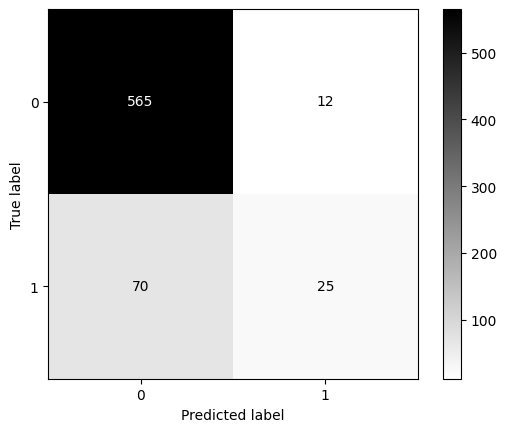


Precisión del modelo:
0.8779761904761905


In [11]:
#Hago la validación de mi modelo Random Forest

# Predicciones
y_pred = model_rf.predict(X_test)

# Métricas de evaluación
print("Matriz de confusión:")
# print(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='binary')
plt.show()

print("\nPrecisión del modelo:")
print(accuracy_score(y_test, y_pred))

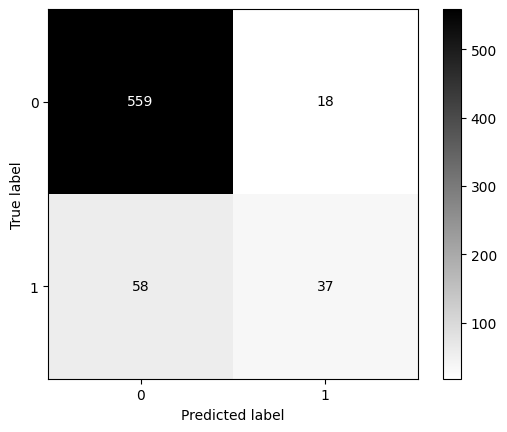


Precisión del modelo:
0.8869047619047619


In [10]:
#Hago la validación de mi modelo Regresión Logística

# Aplicar las mismas transformaciones (imputación y escalado) a X_test
X_test_imputed = imputer.transform(X_test) # Usar el imputer ya ajustado
X_test_scaled = scaler_logr.transform(X_test_imputed) # Usar el scaler ya ajustado

# Predicciones
y_pred = model_logr.predict(X_test_scaled)

# Métricas de evaluación
# print(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='binary')
plt.show()

print("\nPrecisión del modelo:")
print(accuracy_score(y_test, y_pred))

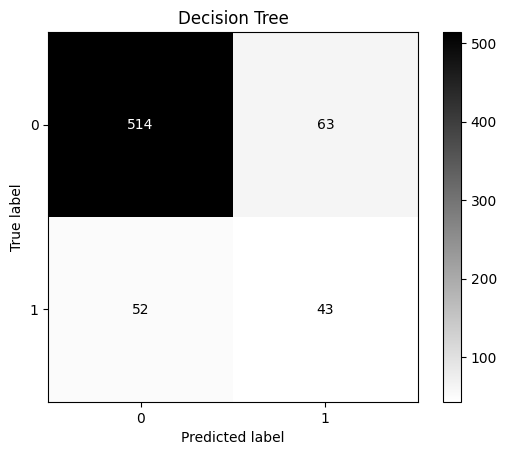


Precisión del modelo:
0.8288690476190477


In [12]:
# Evaluación Decision Tree
y_pred_dt = model_dt.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap='binary')
plt.title('Decision Tree')
plt.show()

print("\nPrecisión del modelo:")
print(accuracy_score(y_test, y_pred_dt))

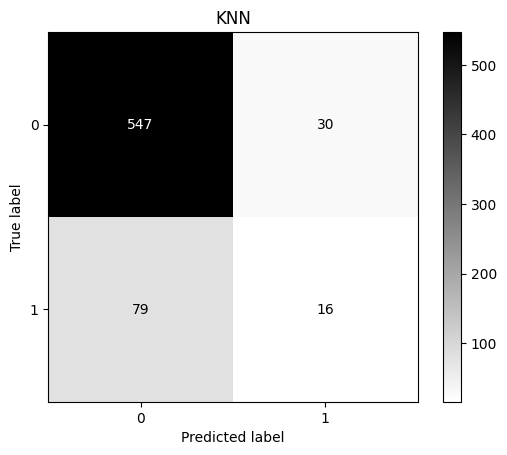


Precisión del modelo:
0.8377976190476191


In [13]:
# Evaluación KNN
y_pred_knn = model_knn.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, cmap='binary')
plt.title('KNN')
plt.show()

print("\nPrecisión del modelo:")
print(accuracy_score(y_test, y_pred_knn))

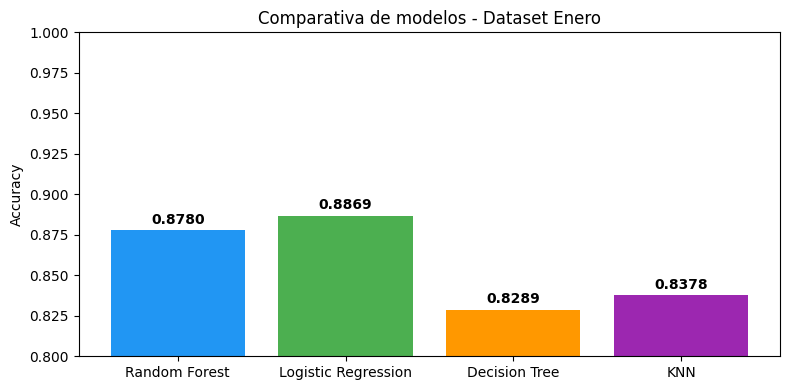

In [15]:
# Comparativa visual de accuracy de los 4 modelos
# Recalculamos cada predicción con su nombre correcto
y_pred_rf = model_rf.predict(X_test)
y_pred_logr = model_logr.predict(X_test_scaled)
y_pred_dt = model_dt.predict(X_test)
y_pred_knn = model_knn.predict(X_test)  # <- cambia X_test si el tuyo usa otro nombre

modelos_nombres = ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_logr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_knn)
]

plt.figure(figsize=(8, 4))
bars = plt.bar(modelos_nombres, accuracies, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparativa de modelos - Dataset Enero')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Esto lo hacemos como comentamos con diversos modelos que sean de aplicación
para este dataset y validamos cual es el que mejor funciona, en este caso el Random Forest tiene mayor precisión y mayor accuracy.**

7 - Guardar el modelo

*   Guardamos el modelo entrenado en un archivo .PKl para reutilizarlo sin tener que volver a entrenarlo.
*   Guardamos el que funcione mejor para poder hacer nuestras validaciones.


In [16]:
# Guardar el modelo entrenado
joblib.dump(model_logr, 'logistic_regression_model.pkl')
print("Modelo guardado como 'logistic_regression_model.pkl'.")

Modelo guardado como 'logistic_regression_model.pkl'.


En definitiva que tenemos que hacer siempre que nos enfrentemos a un problema de aprendizaje supervisado?


0.  Importamos todas las librerías necesarias para nuestro código
1.  Cargamos y exploramos los datos
2.  Preparamos los datos eliminando columnas irrelevantes, codificando categóricas y escalando numéricas.
3.  Dividimos los datos para entrenar y evaluar el modelo
4.  Entrenamos un modelo
5.  Evaluamos el rendimiento del modelo con métricas estándar
6.  Guardamos el modelo para futuras predicciones sobre datasets similares.




8 - Reutilizar Modelos

Ahora bien... Se nos abre un mundo de posibilidades... Que ocurre si queremos probar nuestro modelo en otro DataSet? Por ejemplo si recibo nuevos datos etiquetados en un nuevo mes...
Tenemos que realizar una serie de adaptaciones y podremos usarlo.

In [17]:
# 1. Cargar el nuevo dataset
from google.colab import files
uploaded = files.upload()  # Esto abrirá un cuadro de diálogo para que selecciones el archivo

Saving marketing_campaign_retail_Febrero.xlsx to marketing_campaign_retail_Febrero.xlsx


Una vez cargado el nuevo dataset lo metemos en un data frame al cual vamos a llamar new_data... el anterior se llamaba data, así más fácil

In [18]:
new_dataset_path = 'marketing_campaign_retail_Febrero.xlsx'
new_data = pd.read_excel(new_dataset_path)

# Inspección inicial
print("Primeras filas del dataset:")
display(new_data.head())

#print("\nInformación del dataset:")
#new_data.info()

Primeras filas del dataset:


,Mes,Client ID,Year_Birth,Columna Extra D,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,Febrero,5524,1957,D,Graduation,Single,58138.0,0,0,2012-09-04,...,7,0,0,0,0,0,0,3,11,1
1,Febrero,2174,1954,D,Graduation,Single,46344.0,1,1,2014-03-08,...,5,0,0,0,0,0,0,3,11,0
2,Febrero,4141,1965,D,Graduation,Together,71613.0,0,0,2013-08-21,...,4,0,0,0,0,0,0,3,11,0
3,Febrero,6182,1984,D,Graduation,Together,26646.0,1,0,2014-02-10,...,6,0,0,0,0,0,0,3,11,0
4,Febrero,5324,1981,D,PhD,Married,58293.0,1,0,2014-01-19,...,5,0,0,0,0,0,0,3,11,0


9 - Aplicamos PreProcesado de Datos

En cuanto al preprocesado... se deben procesar los datos en el nuevo dataset de la misma manera que se procesaron en el entrenamiento del modelo, al final es como sumar manzanas con manzanas... si no le pasamos los mismos datos y con la misma tipología no va a funcionar!

In [19]:
import pandas as pd

# Excluir columnas que no estaban en el entrenamiento
exclude_columns = ['Mes', 'Client ID', 'Dt_Customer', 'Columna Extra D', 'Columna Extra M']
feature_columns = [col for col in new_data.columns if col not in exclude_columns]
new_data_filtered = new_data[feature_columns]

# Rellenar nulos de Income
new_data_filtered['Income'] = new_data_filtered['Income'].fillna(new_data_filtered['Income'].mean())

# One-Hot Encoding
new_data_encoded = pd.get_dummies(new_data_filtered, columns=categorical_columns, drop_first=True)

# Separar X e y
X_Feb = new_data_encoded.drop(columns=['Response'])
y_Feb = new_data_encoded['Response']

# ⚠️ Alinear columnas con las del entrenamiento (clave)
X_Feb = X_Feb.reindex(columns=X.columns, fill_value=0)

# Escalar con el mismo scaler del entrenamiento
X_Feb[numerical_columns] = scaler.transform(X_Feb[numerical_columns])

print("Valores nulos:", new_data_encoded.isnull().sum().sum())
print("Datos preprocesados:")
display(X_Feb.head())


Valores nulos: 0
Datos preprocesados:


/tmp/ipykernel_1606/2373230424.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_filtered['Income'] = new_data_filtered['Income'].fillna(new_data_filtered['Income'].mean())


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,-0.985345,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
1,-1.235733,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
2,-0.317643,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
3,1.268149,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
4,1.017761,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,-1.006270,-0.444816,1.899751,-0.036621,-0.339909,1.261980,-0.522233,-0.591099,-0.188676,-0.029894


10 - Validamos nuestro modelo con el nuevo Dataset de validación, un Dataset que viene etiquetado nuevamente, si la precisión que tiene nos convence podremos pasar a utilizarlo para el futuro sin tener etiquetas de los datos... por ejemplo que va pasar en Marzo.

Matriz de confusión:


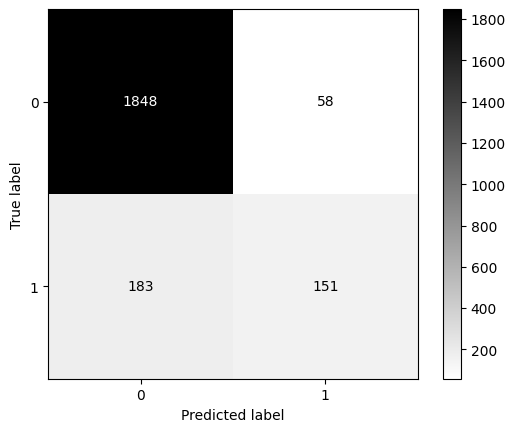


Precisión del modelo:
0.8924107142857143


In [20]:
# Separar en características (X) y objetivo (y)
X_Feb = new_data_encoded.drop(columns=["Response"])
y_Feb = new_data_encoded["Response"]

# Aplicar las mismas transformaciones (imputación y escalado) a X_Feb
# Es crucial usar los mismos imputer y scaler ajustados en el set de entrenamiento
X_Feb_imputed = imputer.transform(X_Feb)
X_Feb_scaled = scaler_logr.transform(X_Feb_imputed)

# Predicciones
y_pred_logr = model_logr.predict(X_Feb_scaled)

# Asegurar que y_pred_logr es de tipo entero para evitar errores de tipo en la matriz de confusión
y_pred_logr = y_pred_logr.astype(int)

# Métricas de evaluación
print("Matriz de confusión:")
ConfusionMatrixDisplay.from_predictions(y_Feb, y_pred_logr, cmap='binary')
plt.show()

print("\nPrecisión del modelo:")
print(accuracy_score(y_Feb, y_pred_logr))

11 - Validación finalizada

He validado mi modelo y veo que funciona bien con datos nuevos, la precisión ha caído ligeramente pero nada significativo con lo cual estoy preparado para usarlo en el futuro con datos no etiquetados.

Voy a cargarlos...

In [21]:
# Cargar el nuevo dataset sin etiquetado, vamos a predecir el futuro!
from google.colab import files
uploaded = files.upload()  # Esto abrirá un cuadro de diálogo para que selecciones el archivo

Saving marketing_campaign_retail_Marzo.xlsx to marketing_campaign_retail_Marzo.xlsx


In [22]:
new_dataset_path = 'marketing_campaign_retail_Marzo.xlsx'
new_data_Marzo = pd.read_excel(new_dataset_path)

# Inspección inicial
print("Primeras filas del dataset:")
display(new_data_Marzo.head())

#print("\nInformación del dataset:")
#new_data_Marzo.info()

Primeras filas del dataset:


,Mes,Client ID,Year_Birth,Columna Extra D,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
0,Marzo,5524,1957,D,Graduation,Single,58138.0,0,0,2012-09-04,...,4,7,0,0,0,0,0,0,3,11
1,Marzo,2174,1954,D,Graduation,Single,46344.0,1,1,2014-03-08,...,2,5,0,0,0,0,0,0,3,11
2,Marzo,4141,1965,D,Graduation,Together,71613.0,0,0,2013-08-21,...,10,4,0,0,0,0,0,0,3,11
3,Marzo,6182,1984,D,Graduation,Together,26646.0,1,0,2014-02-10,...,4,6,0,0,0,0,0,0,3,11
4,Marzo,5324,1981,D,PhD,Married,58293.0,1,0,2014-01-19,...,6,5,0,0,0,0,0,0,3,11


12 - Predigo el futuro

Esto lo hago sobre mi nuevo dataset, pero como hemos visto antes, no puedo pasar por el modelo datos que no he preprocesado... vamos a ello nuevamente!

In [23]:
import pandas as pd

# 2. Preprocesar el nuevo dataset (Marzo)
# Asegúrate de usar las mismas columnas y transformaciones que en el entrenamiento

# Use the global `categorical_columns` (defined in DeAN0DYMmYmn) for one-hot encoding.
# Define `exclude_columns_Marzo` consistent with previous preprocessing for March data
# Based on new_data_Marzo, 'Columna Extra M' is not present, so we exclude 'Columna Extra D'.
exclude_columns_Marzo = ['Mes','Client ID','Dt_Customer', 'Columna Extra D','Columna Extra M']

# Filter columns for features (X_Marzo), excluding irrelevant ones.
# We no longer separate a 'Response' column as this is unlabeled data for prediction.
X_Marzo_raw = new_data_Marzo.drop(columns=exclude_columns_Marzo)

# Codificación de variables categóricas con One-Hot Encoding
X_Marzo_encoded = pd.get_dummies(X_Marzo_raw, columns=categorical_columns, drop_first=True)

# Ensure columns of X_Marzo_encoded match the training data (X.columns).
# Add missing columns with fill_value=0 and reorder existing ones.
X_Marzo_aligned = X_Marzo_encoded.reindex(columns=X.columns, fill_value=0)

print("Valores nulos en el dataset (Marzo) antes de imputación:")
print(X_Marzo_aligned.isnull().sum().sum())

# Aplicar imputación usando el imputer ajustado en el set de entrenamiento
X_Marzo_imputed_array = imputer.transform(X_Marzo_aligned)

print("Valores nulos en el dataset (Marzo) después de imputación:")
# Check for NaNs after imputation (should be 0 if imputer is working correctly)
print(pd.DataFrame(X_Marzo_imputed_array).isnull().sum().sum())

# Escalar variables numéricas usando el scaler ajustado en el set de entrenamiento
X_Marzo_scaled_array = scaler_logr.transform(X_Marzo_imputed_array)

# Create a DataFrame for consistency and to retain column names for clarity
X_Marzo_final = pd.DataFrame(X_Marzo_scaled_array, columns=X_Marzo_aligned.columns)

print("Datos preprocesados (Marzo) para predicción:")
display(X_Marzo_final.head())

Valores nulos en el dataset (Marzo) antes de imputación:
24
Valores nulos en el dataset (Marzo) después de imputación:
0
Datos preprocesados (Marzo) para predicción:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,-1.013121,0.231278,-0.852404,-0.914466,0.333272,0.990522,1.565211,1.618303,2.497948,1.498352,...,0.977298,-0.431372,-0.526187,-0.043783,-0.335926,-0.803325,1.940607,-0.594046,-0.181489,-0.035737
1,-1.264863,-0.212178,0.998801,0.923845,-0.361682,-0.844595,-0.634369,-0.695862,-0.651499,-0.631671,...,0.977298,-0.431372,-0.526187,-0.043783,-0.335926,-0.803325,1.940607,-0.594046,-0.181489,-0.035737
2,-0.341810,0.737941,-0.852404,-0.914466,-0.778655,0.375875,0.579192,-0.177318,1.367852,-0.142011,...,0.977298,-0.431372,-0.526187,-0.043783,-0.335926,-0.803325,-0.515303,1.683372,-0.181489,-0.035737
3,1.252554,-0.952826,0.998801,-0.914466,-0.778655,-0.844595,-0.558521,-0.635865,-0.503290,-0.582705,...,0.977298,-0.431372,-0.526187,-0.043783,-0.335926,-0.803325,-0.515303,1.683372,-0.181489,-0.035737
4,1.000812,0.237106,0.998801,-0.914466,1.584191,-0.368170,0.427497,-0.215887,0.163652,0.004887,...,-1.023229,-0.431372,1.900464,-0.043783,-0.335926,1.244827,-0.515303,-0.594046,-0.181489,-0.035737


In [39]:
# 3. Realizar predicciones

# Obtenemos predicciones utilizando nuestro mejor modelo entrenado (model_logr)
# Usamos X_Marzo_final, que es el dataset de Marzo preprocesado y escalado
probabilities = model_logr.predict_proba(X_Marzo_final)

# Clase predicha
predicted_classes = probabilities.argmax(axis=1)

# Probabilidad de la clase predicha
predicted_probabilities = probabilities[:, 1]

# Crear un DataFrame con las predicciones y sus probabilidades
results = pd.DataFrame({
    'Prediccion': predicted_classes,
    'Probabilidad': predicted_probabilities
})

# Combinar con el dataset original de Marzo (new_data_Marzo)
# Asegúrate de que los índices coincidan al concatenar
final_results = pd.concat([new_data_Marzo.reset_index(drop=True), results], axis=1)

# Mostrar las primeras filas
print(final_results.sort_values('Probabilidad', ascending=False).head(20))

      level_0  index    Mes  Client ID  Year_Birth Columna Extra D  \
252       252    252  Marzo      10089        1974               D   
1961     1961   1961  Marzo       3009        1962               D   
430       430    430  Marzo       3725        1961               D   
336       336    336  Marzo       7381        1968               D   
1845     1845   1845  Marzo       7872        1975               D   
586       586    586  Marzo       9058        1955               D   
753       753    753  Marzo       3667        1969               D   
1722     1722   1722  Marzo        569        1991               D   
987       987    987  Marzo       4580        1969               D   
1710     1710   1710  Marzo        477        1986               D   
1334     1334   1334  Marzo       2535        1978               D   
1528     1528   1528  Marzo        830        1987               D   
1308     1308   1308  Marzo       5758        1982               D   
2167     2167   2167

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Y ahora como podemos comparar esta información con el Dataset original de Marzo? No olvidemos que el dataset que hemos trabajado ha sido modificado en el preprocesado para poder aplicar nuestro modelo...

In [40]:
# Verificar las primeras filas del dataset original (en este caso el nuevo de marzo)
print(new_data_Marzo.head())


   level_0  index    Mes  Client ID  Year_Birth Columna Extra D   Education  \
0        0      0  Marzo       5524        1957               D  Graduation   
1        1      1  Marzo       2174        1954               D  Graduation   
2        2      2  Marzo       4141        1965               D  Graduation   
3        3      3  Marzo       6182        1984               D  Graduation   
4        4      4  Marzo       5324        1981               D         PhD   

  Marital_Status   Income  Kidhome  ...  NumStorePurchases NumWebVisitsMonth  \
0         Single  58138.0        0  ...                  4                 7   
1         Single  46344.0        1  ...                  2                 5   
2       Together  71613.0        0  ...                 10                 4   
3       Together  26646.0        1  ...                  4                 6   
4        Married  58293.0        1  ...                  6                 5   

   AcceptedCmp3  AcceptedCmp4 AcceptedCmp5  

Añadimos un indice al dataset que hemos cargado y sobre el que vamos a realizar las predicciones...

In [44]:
if 'level_0' in new_data_Marzo.columns:
    new_data_Marzo = new_data_Marzo.drop(columns=['level_0'])
if 'index' in new_data_Marzo.columns:
    new_data_Marzo = new_data_Marzo.drop(columns=['index'])

# Ahora, reiniciamos el índice de forma limpia
new_data_Marzo.reset_index(drop=True, inplace=True)

Combinamos los resultado del dataset que hemos validado con las predicciones que hemos realizado, escogemos solo aquellas columnas que nos sean de interés...

In [45]:
# Combinar usando un identificador común (si existe)
combined_results = pd.merge(new_data_Marzo, final_results, left_index=True, right_index=True)

# Verificar las primeras filas del DataFrame combinado seleccionando las columnas que consideremos relevantes

show_columns = ['Mes_x','Client ID_x','Year_Birth_x','Income_x','Kidhome_x','Teenhome_x','Recency_x','Prediccion','Probabilidad']
comparison_results=combined_results[show_columns]

comparison_results=comparison_results.rename(columns={'Mes_x': 'Mes', 'Client ID_x': 'Client ID', 'Year_Birth_x': 'Year_Birth', 'Income_x': 'Income', 'Kidhome_x': 'Kidhome', 'Teenhome_x': 'Teenhome', 'Recency_x': 'Recency', 'Prediccion' : 'Conversion'})

print(comparison_results.head())

     Mes  Client ID  Year_Birth   Income  Kidhome  Teenhome  Recency  \
0  Marzo       5524        1957  58138.0        0         0       58   
1  Marzo       2174        1954  46344.0        1         1       38   
2  Marzo       4141        1965  71613.0        0         0       26   
3  Marzo       6182        1984  26646.0        1         0       26   
4  Marzo       5324        1981  58293.0        1         0       94   

   Conversion  Probabilidad  
0           1      0.588287  
1           0      0.034051  
2           0      0.030622  
3           0      0.038313  
4           0      0.026307  


En caso de querer extraer la información para posteriores análisis, enriquecimiento de CdM o cualquier tipo de reporting lo podemos hacer, simplemente se deben escribir las sentencias que vienen a continuación...

In [46]:
# Guardar en un archivo Excel
comparison_results.to_excel('marketing_campaign_retail_Marzo_with_Predictions.xlsx', index=False)

print("Resultados combinados guardados en 'marketing_campaign_retail_Marzo_with_Predictions.xlsx'")

Resultados combinados guardados en 'marketing_campaign_retail_Marzo_with_Predictions.xlsx'


In [48]:
from google.colab import files
files.download('marketing_campaign_retail_Marzo_with_Predictions.xlsx')
files.download('logistic_regression_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>